In [1]:
from datasets import load_dataset

# Dataset has 50 subreddit splits (e.g. 'gaming', 'todayilearned', etc.)
# Loading without a split gives a DatasetDict keyed by subreddit name
reddit = load_dataset("HuggingFaceGECLM/REDDIT_comments", streaming=True)

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/45 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

## Exploratory Analysis

In [2]:
# Show available splits (subreddits) and peek at the first record
print("Available splits (subreddits):")
print(list(reddit.keys()))
print()

# Peek at the first record from the first split
first_split = list(reddit.keys())[0]
sample = next(iter(reddit[first_split]))
print(f"Fields (from '{first_split}' split):")
print(list(sample.keys()))
print()
for k, v in sample.items():
    preview = str(v)[:200] + "..." if len(str(v)) > 200 else str(v)
    print(f"  {k}: {preview}")

Available splits (subreddits):
['AskHistorians', 'DIY', 'Damnthatsinteresting', 'Documentaries', 'EatCheapAndHealthy', 'Fantasy', 'Fitness', 'Foodforthought', 'Games', 'GetMotivated', 'IAmA', 'IWantToLearn', 'LifeProTips', 'Showerthoughts', 'SkincareAddiction', 'UpliftingNews', 'WritingPrompts', 'YouShouldKnow', 'askscience', 'bestof', 'boardgames', 'bodyweightfitness', 'books', 'buildapc', 'changemyview', 'explainlikeimfive', 'femalefashionadvice', 'gadgets', 'gaming', 'gardening', 'history', 'ifyoulikeblank', 'lifehacks', 'malefashionadvice', 'mildlyinteresting', 'personalfinance', 'philosophy', 'podcasts', 'programming', 'relationship_advice', 'science', 'scifi', 'socialskills', 'space', 'sports', 'suggestmeabook', 'technology', 'tifu', 'todayilearned', 'travel']

Fields (from 'AskHistorians' split):
['archived', 'author', 'author_fullname', 'body', 'comment_type', 'controversiality', 'created_utc', 'edited', 'gilded', 'id', 'link_id', 'locked', 'name', 'parent_id', 'permalink', 're

  AskHistorians                      : 200 records  (running total: 200)
  DIY                                : 200 records  (running total: 400)
  Damnthatsinteresting               : 200 records  (running total: 600)
  Documentaries                      : 200 records  (running total: 800)
  EatCheapAndHealthy                 : 200 records  (running total: 1000)
  Fantasy                            : 200 records  (running total: 1200)
  Fitness                            : 200 records  (running total: 1400)
  Foodforthought                     : 200 records  (running total: 1600)
  Games                              : 200 records  (running total: 1800)
  GetMotivated                       : 200 records  (running total: 2000)
  IAmA                               : 200 records  (running total: 2200)
  IWantToLearn                       : 200 records  (running total: 2400)
  LifeProTips                        : 200 records  (running total: 2600)
  Showerthoughts                     : 200

/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_54595/2891558891.py:33: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_ym   = s.dt.to_period("M").value_counts().sort_index()


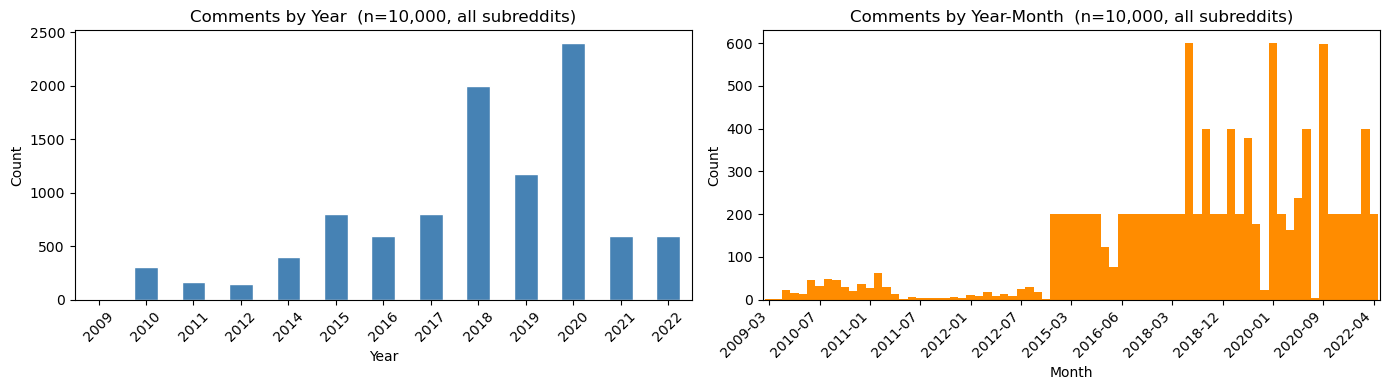

In [3]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# .shard() does not exist on IterableDataset. For each subreddit split,
# shuffle with a buffer and take the desired number of records in one pass.
RECORDS_PER_SPLIT = 200   # equivalent to 10 shards × 20 records from before
BUFFER_SIZE       = 5_000
SEED              = 42

all_splits = list(reddit.keys())

timestamps = []
subreddits = []

for split_name in all_splits:
    shuffled_split = reddit[split_name].shuffle(buffer_size=BUFFER_SIZE, seed=SEED)
    count = 0
    for record in shuffled_split.take(RECORDS_PER_SPLIT):
        ts = record.get("created_utc")
        if ts:
            timestamps.append(int(ts))
            subreddits.append(split_name)
            count += 1
    print(f"  {split_name:<35}: {count} records  (running total: {len(timestamps)})")

print(f"\nSampled {len(timestamps)} records across {len(all_splits)} subreddits")

# Parse Unix timestamps
dates = pd.to_datetime(timestamps, unit="s", utc=True)
s = pd.Series(dates)
by_year = s.dt.year.value_counts().sort_index()
by_ym   = s.dt.to_period("M").value_counts().sort_index()

# Plot date distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

by_year.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Comments by Year  (n={len(timestamps):,}, all subreddits)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

by_ym_ts = by_ym.copy()
by_ym_ts.index = by_ym_ts.index.to_timestamp()
by_ym_ts.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="none", width=1.0)
axes[1].set_title(f"Comments by Year-Month  (n={len(timestamps):,}, all subreddits)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
n_ticks = len(by_ym_ts)
step = max(1, n_ticks // 12)
axes[1].set_xticks(range(0, n_ticks, step))
axes[1].set_xticklabels(
    [f"{by_ym_ts.index[i].year}-{str(by_ym_ts.index[i].month).zfill(2)}"
     for i in range(0, n_ticks, step)],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

In [4]:
# Date range, distribution stats, and record count per subreddit
print("=== Date Range ===")
print(f"  Earliest : {s.min()}")
print(f"  Latest   : {s.max()}")
print(f"  Span     : {s.max() - s.min()}")
print()
print("=== Distribution by Year ===")
for year, count in by_year.items():
    bar = "\u2588" * (count * 40 // by_year.max())
    print(f"  {year}  {count:>6}  {bar}")
print()
print("=== Records per Subreddit (sampled) ===")
sub_counts = pd.Series(subreddits).value_counts().sort_values(ascending=False)
for sub, count in sub_counts.items():
    bar = "\u2588" * (count * 40 // sub_counts.max())
    print(f"  {sub:<35} {count:>5}  {bar}")

=== Date Range ===
  Earliest : 2009-03-10 14:15:55+00:00
  Latest   : 2022-04-17 21:02:46+00:00
  Span     : 4786 days 06:46:51

=== Distribution by Year ===
  2009       1  
  2010     309  █████
  2011     167  ██
  2012     145  ██
  2014     400  ██████
  2015     800  █████████████
  2016     600  ██████████
  2017     800  █████████████
  2018    2000  █████████████████████████████████
  2019    1178  ███████████████████
  2020    2400  ████████████████████████████████████████
  2021     600  ██████████
  2022     600  ██████████

=== Records per Subreddit (sampled) ===
  AskHistorians                         200  ████████████████████████████████████████
  IWantToLearn                          200  ████████████████████████████████████████
  buildapc                              200  ████████████████████████████████████████
  Damnthatsinteresting                  200  ████████████████████████████████████████
  Documentaries                         200  ███████████████████████████